Creazione di una rete neurale  artificiale per il
riconoscimento dei numeri scritti da persone in
un dataset di immagini.

In questo esempio è stato utilizzato il dataset [MNIST](https://en.wikipedia.org/wiki/MNIST_database)

In [1]:
# importazione librerie necessarie
# pip install upgrade pandas numpy tensorflow
# pip install upgrade force-reinstall numpy tensorflow scipy
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
import numpy as np

2026-04-22 12:19:16.930143: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# scaricamento del dataset MNIST; la prima volta
# che si esegue potrebbe essere un'operazione
# lenta; fatta una volta il dataset resta nella
# cache del virtual enviroment utilizzato ed i
# successivi richiami sono istantanei
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data(path="mnist.npz")

print(train_images.shape) # (60000, 28, 28)
print(train_labels.shape) # (60000,)

(60000, 28, 28)
(60000,)


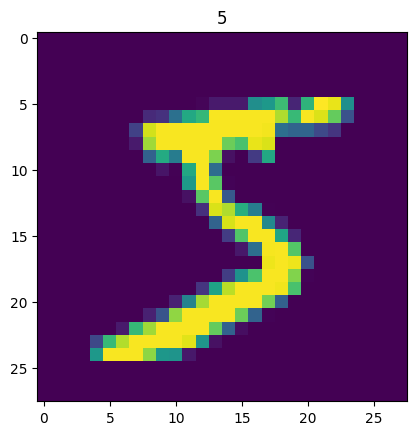

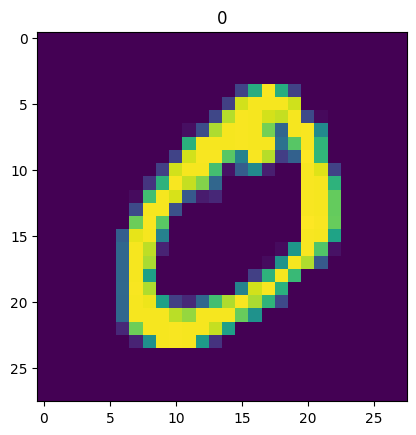

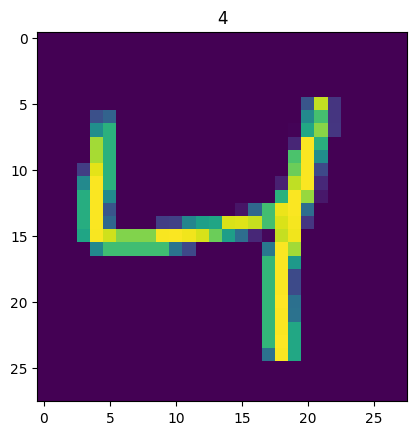

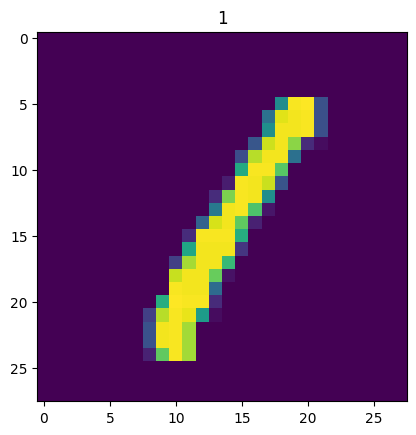

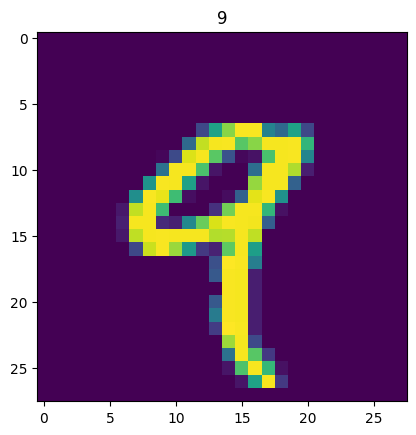

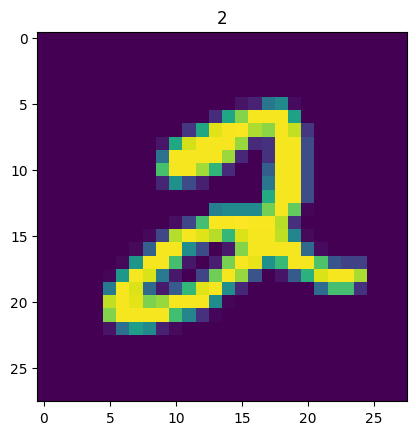

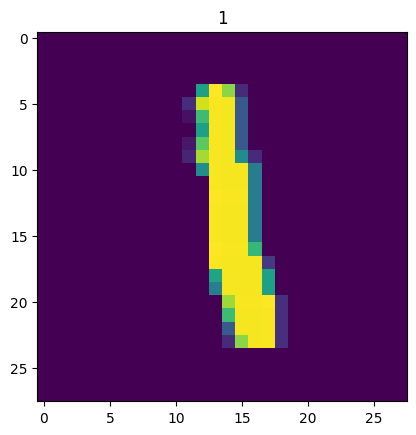

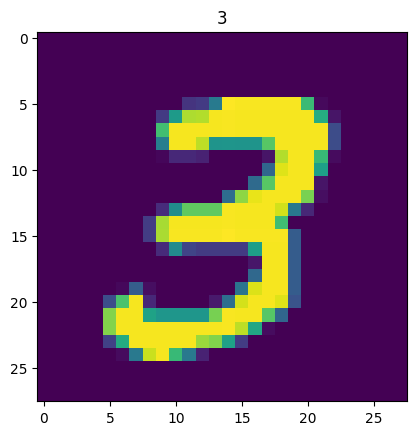

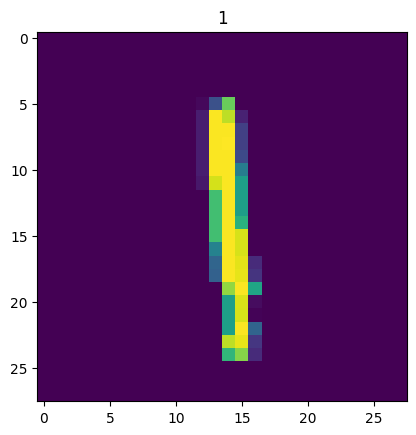

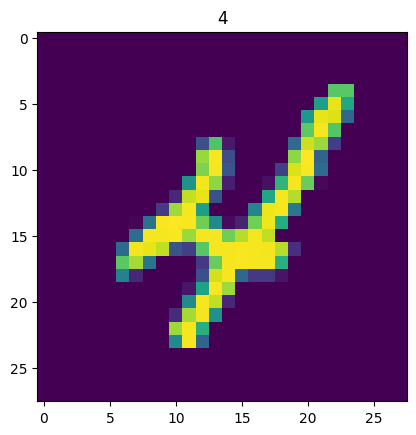

In [3]:
for i in range(10):
    plt.imshow(train_images[i])
    plt.title(train_labels[i])
    plt.show()

In [4]:
# pre-processing dei dataset

# normalizzazione
train_images = (train_images / 255)
test_images = (test_images / 255)

# appiattimento di ogni immagine da un array 28x28 ad un array di 784 pixel
train_images = train_images.reshape((-1, 784))
test_images = test_images.reshape((-1, 784))

print(train_images.shape) # (60000, 784)
print(test_images.shape)  # (10000, 784)

(60000, 784)
(10000, 784)


In [5]:
# trasformazione delle label tramite hot-encoding
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

# esempio di codifica one-hot su un esempio di addestramento:
print(train_labels[42])

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [6]:
# creazione del modello

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# compilazione del modello

model.compile(
  optimizer=Adam(learning_rate=0.005),
  loss='categorical_crossentropy',
  metrics=['accuracy'],
)

In [8]:
# riepilogo del modello compilato

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# addestramento del modello
# nell'oggetto history avremo il resoconto
# dell'addestramento epoca per epoca

history = model.fit(
    x=train_images, # training dataset
    y=train_labels, # training labels
    epochs=10,
    batch_size=250,
    validation_data=(
        test_images, # testing dataset
        test_labels  # testing labels
    )
)

Epoch 1/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8276 - loss: 0.5490 - val_accuracy: 0.9524 - val_loss: 0.1588
Epoch 2/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9591 - loss: 0.1378 - val_accuracy: 0.9623 - val_loss: 0.1216
Epoch 3/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9716 - loss: 0.0938 - val_accuracy: 0.9687 - val_loss: 0.1080
Epoch 4/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9738 - loss: 0.0820 - val_accuracy: 0.9717 - val_loss: 0.0974
Epoch 5/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9812 - loss: 0.0580 - val_accuracy: 0.9666 - val_loss: 0.1137
Epoch 6/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9839 - loss: 0.0513 - val_accuracy: 0.9738 - val_loss: 0.0950
Epoch 7/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9854 - loss: 0.0431 - val_accuracy: 0.9749 - val_loss: 0.0961
Epoch 8/10
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9876 - loss: 0.0391 - val_accuracy: 0.

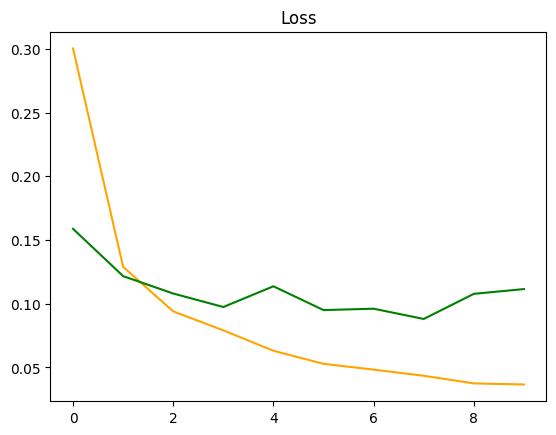

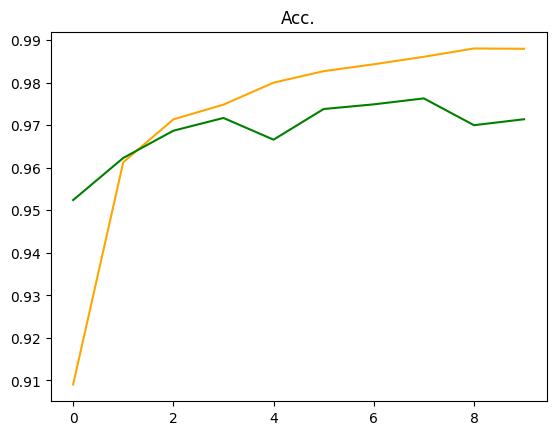

In [10]:
# visualizzazione su grafico
# dell'andamento dell'addestramento

# errore modello
plt.plot(history.history['loss'], color='orange')
plt.plot(history.history['val_loss'], color='green')
plt.title('Loss')
plt.show()

# accuratezza modello
plt.plot(history.history['accuracy'], color='orange')
plt.plot(history.history['val_accuracy'], color='green')
plt.title('Acc.')
plt.show()

In [11]:
# valutazione delle performance del modello

model.evaluate(
  test_images,
  test_labels
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9676 - loss: 0.1303


[0.11146342754364014, 0.9714000225067139]

In [12]:
# predizione delle prime 5  immagini di test..
predictions = model.predict(test_images[:5])
print(np.argmax(predictions, axis=1)) # [7, 2, 1, 0, 4]

# verifica della correttezza della previsione
print(np.argmax(test_labels[:5], axis=1)) # [7, 2, 1, 0, 4]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
[7 2 1 0 4]
[7 2 1 0 4]
